# 主成分分析：PCA（Principal Component Analysis）

PCAは、たくさんある変数を「情報をできるだけ失わない少数の軸」にまとめる手法です。今回のデータでは、1つの画像が784個のピクセル値で表されています。この784個の値をそのまま見るのは難しいので、PCAでPC1、PC2、...という新しい軸に変換し、2次元の散布図や10次元までの関係として見やすくします。

ここでいう**変数**とは、データを説明する列のことです。この課題では `pixel_0` から `pixel_783` までの各ピクセルが変数です。**次元**とは、1つのデータを表すために使う数値の個数です。784個のピクセルで表される画像は784次元のデータ、と考えます。

**この手法で見たいこと**

PCAでは、784次元の画像データを、できるだけ情報を保ったまま少ない次元へ圧縮します。PC1とPC2の散布図を見ると、似ている画像が近くに集まっているか、全体がいくつかのまとまりに分かれているかを確認できます。

**処理の流れ**

1. `MNICT_train.csv` を読み込みます。
2. すべて同じ値になっているピクセル列を除外します。標準偏差が0の列は、標準化すると割り算でNaNが出るためです。
3. 各変数を標準化します。**標準化**とは、平均を0、標準偏差を1にそろえる処理です。
4. PCAを実行し、PC1からPC10までの主成分スコアを計算します。
5. PC1 vs PC2の散布図、寄与率と累積寄与率の図、PC1からPC10までの10×10プロットを作ります。

**数式の考え方**

標準化したデータ行列を $X$ とします。$X$ は「行がサンプル、列が変数」の表です。サンプルとは1枚1枚の画像、変数とは各ピクセル列です。

まず、変数同士がどのように一緒に変化するかを表す分散共分散行列を作ります。

$$
C = \frac{1}{n-1}X^T X
$$

ここで $n$ はサンプル数です。**分散**は「値が平均からどれくらいばらついているか」、**共分散**は「2つの変数が一緒に増えたり減ったりする傾向があるか」を表します。

PCAでは、この $C$ から**固有値**と**固有ベクトル**を求めます。固有ベクトルは新しい軸の向き、固有値はその軸がどれくらい情報、つまりばらつきを持っているかを表します。PCAの新しい軸を**主成分**と呼びます。

主成分スコアは次の式で計算できます。

$$
T = XW
$$

$W$ は固有ベクトルを並べた行列です。$T$ が主成分スコアで、各画像がPC1、PC2、...の上でどの位置にあるかを表します。**スコア**はサンプル側の座標、**ローディング**は変数側、つまり各ピクセルが主成分にどれくらい関係しているかを表す値です。

**寄与率と累積寄与率**

寄与率は、ある主成分が全体の情報のうち何割を説明しているかを表します。第 $j$ 主成分の固有値を $\lambda_j$ とすると、寄与率は次のように書けます。

$$
\text{寄与率}_j = \frac{\lambda_j}{\lambda_1 + \lambda_2 + \cdots + \lambda_p}
$$

累積寄与率は、PC1からその主成分までの寄与率を足し合わせたものです。たとえばPC10までの累積寄与率が0.55なら、最初の10個の主成分で全体のばらつきの約55%を説明している、という意味です。

**図の読み方**

PC1 vs PC2の散布図では、1つの点が1つの画像です。点同士が近いほど、PCAで見た特徴が似ていると考えます。遠く離れている点は、画像の特徴が違う可能性があります。ただし、PC1とPC2だけでは全情報を表していないため、2次元の図だけで完全に判断しないことが大切です。

10×10プロットでは、PC1からPC10までの組み合わせをまとめて見ます。対角線上の図は各主成分の分布、対角線以外の図は2つの主成分の関係です。色分けは、正解ラベルではなく、表示用に取り出したサンプルを標準化済みの元データでk-meansクラスタリングした9個の補助的なグループです。

**メリット**

- 高次元データを少数の軸に圧縮できるため、画像データの全体像を散布図で確認できます。
- 寄与率を見ることで、どの主成分がどれくらい情報を持っているかを数値で確認できます。
- 計算が比較的速く、主成分、スコア、ローディングという形で結果を説明しやすいです。

**デメリット**

- PCAは直線的な変換です。直線的とは、元の変数を足し算と掛け算で組み合わせるという意味です。そのため、曲がった構造や複雑なまとまりは表しにくいことがあります。
- PC1とPC2は分散が大きい方向ですが、分類やクラスタリングに最も役立つ方向とは限りません。
- 主成分は元のピクセルを混ぜて作った軸なので、「この軸はこのピクセルそのものを表す」とは解釈できません。


読み込んだデータ: 60000 サンプル x 784 変数
ゼロ分散の列を 67 個除外しました。解析に使う変数数: 717


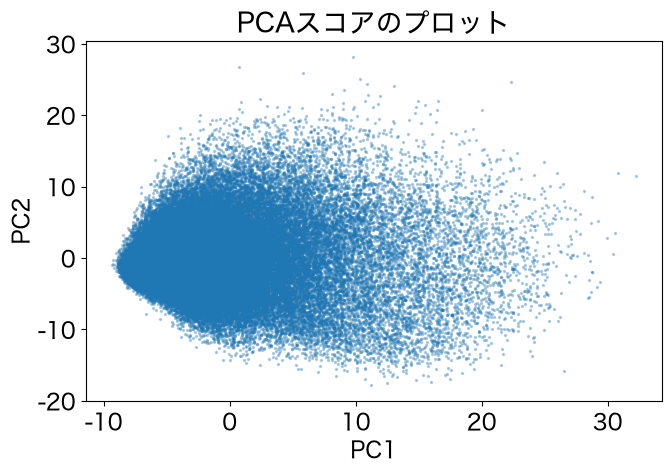

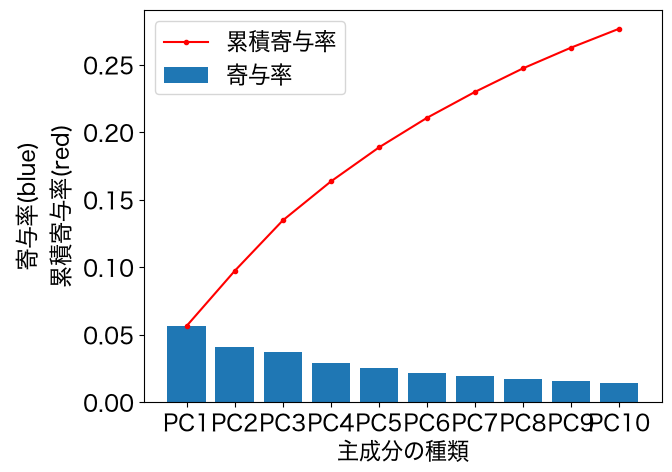

/Users/t-shuichi/Developer/seminar6/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/t-shuichi/Developer/seminar6/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/t-shuichi/Developer/seminar6/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/t-shuichi/Developer/seminar6/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  func(x=vector, **plot_kwargs)
/Users/t-shuichi/Developer/seminar6/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: UserWar

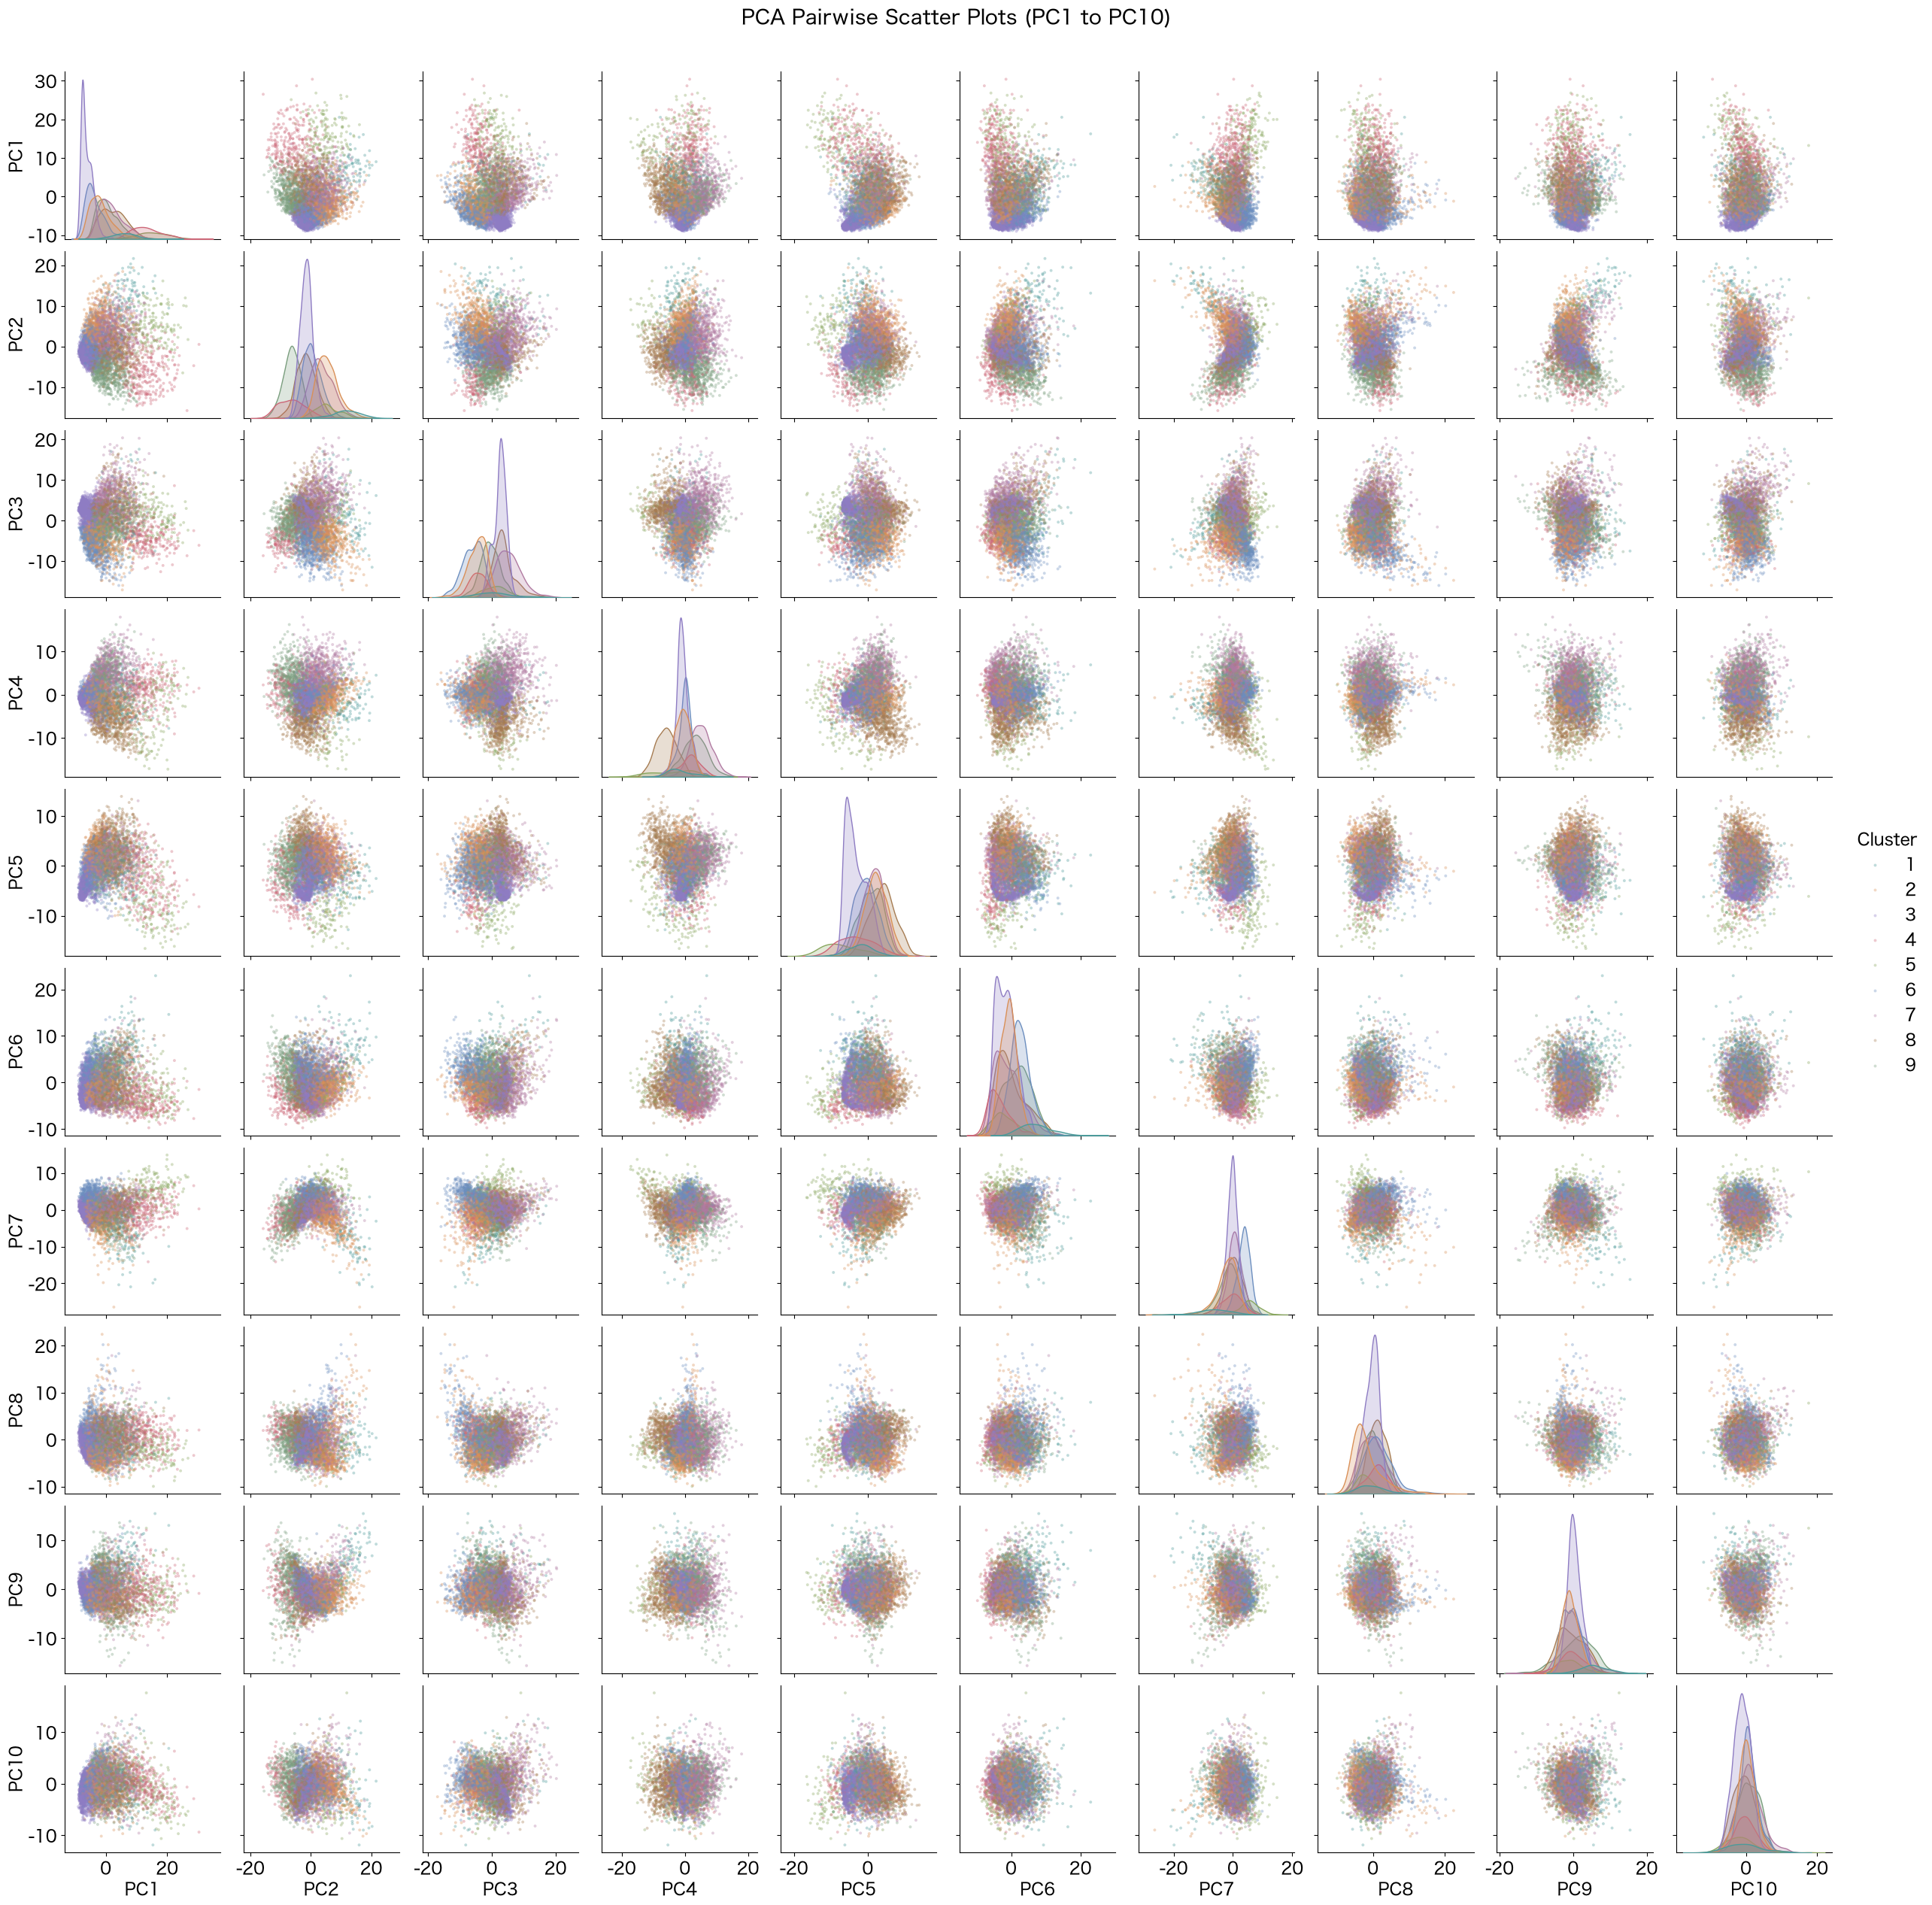

In [55]:
from pathlib import Path
import os
import zipfile

import numpy as np

# MatplotlibやFontconfigのキャッシュ先を、書き込み可能な一時フォルダにします
# これにより、図を表示するときの警告や日本語フォント設定の失敗を減らします
matplotlib_cache_dir = Path('/private/tmp/seminar6_matplotlib_cache')
matplotlib_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(matplotlib_cache_dir))
os.environ.setdefault('XDG_CACHE_HOME', str(matplotlib_cache_dir))

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import BoundaryNorm, ListedColormap
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


def set_japanese_font():
    """Matplotlibの図で日本語が文字化けしないように、日本語フォントを探して設定します。"""
    candidate_fonts = [
        'Hiragino Sans',
        'Hiragino Maru Gothic Pro',
        'Yu Gothic',
        'Meiryo',
        'Noto Sans CJK JP',
        'Noto Sans JP',
        'IPAexGothic',
        'AppleGothic',
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in candidate_fonts:
        if font_name in available_fonts:
            plt.rcParams['font.family'] = font_name
            break
    plt.rcParams['axes.unicode_minus'] = False  # マイナス記号が□になるのを防ぎます


set_japanese_font()


# クラスター表示に使う色はここで変えられます
# 左から順に、クラスター1, 2, 3, ... の色として使われます
# 色はカラーコードで指定します。例: '#4C9A9A' はくすみ系の青緑です
cluster_colors = ['#4C9A9A', '#D99058', '#8E7CC3', '#CC6677', '#88A65E', '#6C8EBF', '#B07AA1', '#A67C52', '#7A9E7E', '#C9A227']


def make_cluster_colormap(number_of_clusters):
    """クラスター番号ごとに固定色を割り当てるためのカラーマップを作ります。"""
    if number_of_clusters > len(cluster_colors):
        raise ValueError('cluster_colors の色数がクラスター数より少ないです。色を追加してください。')
    cmap = ListedColormap(cluster_colors[:number_of_clusters])
    norm = BoundaryNorm(range(1, number_of_clusters + 2), cmap.N)
    return cmap, norm

# ノートブックをプロジェクト直下・prac直下のどちらから実行してもCSVまたはzipを見つけるための準備
candidate_paths = [
    Path('MNICT_train.csv'),
    Path('prac') / 'MNICT_train.csv',
    Path('/Users/t-shuichi/Developer/seminar6/prac/MNICT_train.csv'),
]
zip_candidate_paths = [
    Path('MNICT_train.csv.zip'),
    Path('prac') / 'MNICT_train.csv.zip',
    Path('/Users/t-shuichi/Developer/seminar6/prac/MNICT_train.csv.zip'),
]

dataset_path = None
for candidate_path in candidate_paths:
    if candidate_path.exists():
        dataset_path = candidate_path
        break

zip_dataset_path = None
if dataset_path is None:
    for candidate_path in zip_candidate_paths:
        if candidate_path.exists():
            zip_dataset_path = candidate_path
            break

if dataset_path is None and zip_dataset_path is None:
    raise FileNotFoundError('MNICT_train.csv または MNICT_train.csv.zip が見つかりません。ノートブックの場所かCSVのパスを確認してください。')

output_dir = (dataset_path or zip_dataset_path).parent

# データの読み込み。index_col=0 により、先頭列のサンプル番号を行名として使います
if dataset_path is not None:
    dataset = pd.read_csv(dataset_path, index_col=0)
else:
    with zipfile.ZipFile(zip_dataset_path) as zipped_file:
        with zipped_file.open('MNICT_train.csv') as csv_file:
            dataset = pd.read_csv(csv_file, index_col=0)

print(f'読み込んだデータ: {dataset.shape[0]} サンプル x {dataset.shape[1]} 変数')

# すべて同じ値の列は標準偏差が0になり、オートスケーリングでNaNが出るため除外します
standard_deviations = dataset.std()
nonzero_variance_columns = standard_deviations[standard_deviations != 0].index
dataset_for_analysis = dataset.loc[:, nonzero_variance_columns]
removed_columns = dataset.shape[1] - dataset_for_analysis.shape[1]
print(f'ゼロ分散の列を {removed_columns} 個除外しました。解析に使う変数数: {dataset_for_analysis.shape[1]}')

# PCAやUMAPでは変数ごとのスケールをそろえるため、平均0・標準偏差1にオートスケーリングします
autoscaled_dataset = (dataset_for_analysis - dataset_for_analysis.mean()) / dataset_for_analysis.std()

# PCAは最初の10主成分を計算します。散布図・寄与率図・10x10プロットでこの結果を使います
number_of_components = 10
pca = PCA(n_components=number_of_components, random_state=0)
pca_scores = pca.fit_transform(autoscaled_dataset)

# ローディングを保存します。各ピクセル変数が各主成分にどの程度関係するかを表します
loading_columns = [f'PC{i}' for i in range(1, number_of_components + 1)]
loadings = pd.DataFrame(pca.components_.T, index=dataset_for_analysis.columns, columns=loading_columns)
loadings.to_csv(output_dir / 'pca_loadings.csv')

# PCAスコアを保存します。各サンプルを主成分軸上の座標で表したものです
score = pd.DataFrame(pca_scores, index=dataset.index, columns=loading_columns)
score.to_csv(output_dir / 'pca_score.csv')

# 第1主成分と第2主成分の散布図
plt.rcParams['font.size'] = 16
plt.figure(figsize=(7, 5))
plt.scatter(score['PC1'], score['PC2'], s=2, alpha=0.3)
plt.title('PCAスコアのプロット')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# 寄与率と累積寄与率を保存します
contribution_ratios = pd.Series(
    pca.explained_variance_ratio_,
    index=loading_columns,
    name='contribution_ratio',
)
cumulative_contribution_ratios = contribution_ratios.cumsum().rename('cumulative_contribution_ratio')
cont_cumcont_ratios = pd.concat([contribution_ratios, cumulative_contribution_ratios], axis=1)
cont_cumcont_ratios.to_csv(output_dir / 'pca_cont_cumcont_ratios.csv')

# 寄与率を棒グラフ、累積寄与率を折れ線グラフで描画します
plt.figure(figsize=(7, 5))
x_axis = range(1, number_of_components + 1)
plt.bar(x_axis, contribution_ratios, align='center', label='寄与率')
plt.plot(x_axis, cumulative_contribution_ratios, 'r.-', label='累積寄与率')
plt.xticks(x_axis, [f'PC{i}' for i in x_axis])
plt.xlabel('主成分の種類')
plt.ylabel('寄与率(blue)\n累積寄与率(red)')
plt.legend()
plt.tight_layout()
plt.show()

# 60,000点すべてで10x10を描くと重くなるため、表示用には最大5,000点を固定乱数でサンプリングします
# PCAスコアやCSV保存は全サンプルで行っています
plot_data = score.sample(n=min(5000, len(score)), random_state=0).copy()

# 10x10プロットの色分けは、PCAスコアではなく標準化済みの元データに対するk-meansで作ります
# ここでは表示用に選んだサンプルだけを、9個の補助クラスタに色分けしています
number_of_pairplot_clusters = 9
pairplot_kmeans = KMeans(n_clusters=number_of_pairplot_clusters, random_state=0, n_init='auto')
plot_data['Cluster'] = pairplot_kmeans.fit_predict(autoscaled_dataset.loc[plot_data.index]) + 1

sns.pairplot(
    plot_data,
    vars=loading_columns,
    hue='Cluster',
    palette=cluster_colors,
    corner=False,
    diag_kind='kde',
    plot_kws={'s': 8, 'alpha': 0.35, 'linewidth': 0},
    diag_kws={'fill': True, 'alpha': 0.25},
)
plt.suptitle('PCA Pairwise Scatter Plots (PC1 to PC10)', y=1.02)
plt.show()


## 元画像とPCAローディングの確認

散布図だけでは、もとのサンプルがどのような画像か分かりにくいため、代表的な手書き数字画像を確認します。さらに、PCAローディングを28×28画像に戻して表示し、各主成分が画像のどの場所を強く見ているかを確認します。


In [ ]:
# 元データの一部を28x28画像として表示します
preview_sample_size = min(25, len(dataset))
preview_indices = dataset.sample(n=preview_sample_size, random_state=0).index

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.ravel()

for ax, sample_id in zip(axes, preview_indices):
    image = dataset.loc[sample_id].to_numpy().reshape(28, 28)
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'ID: {sample_id}', fontsize=9)
    ax.axis('off')

for ax in axes[preview_sample_size:]:
    ax.axis('off')

plt.suptitle('元画像のサンプル')
plt.tight_layout()
plt.show()

# PC1からPC10までのローディングを画像として表示します
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for component_index, ax in enumerate(axes):
    loading_values = pd.Series(pca.components_[component_index], index=dataset_for_analysis.columns)
    loading_image = loading_values.reindex(dataset.columns, fill_value=0).to_numpy().reshape(28, 28)
    vmax = np.abs(loading_image).max()
    image = ax.imshow(loading_image, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(f'PC{component_index + 1}')
    ax.axis('off')

fig.colorbar(image, ax=axes, shrink=0.75, label='ローディング')
plt.suptitle('PCAローディング画像')
plt.tight_layout()
plt.show()



# 一様多様体近似・射影法：UMAP（Uniform Manifold Approximation and Projection） 

UMAPは、近くにあるデータ同士の関係をなるべく保ったまま、2次元に圧縮する可視化手法です。PCAが「分散が大きい方向」を探すのに対して、UMAPは「近所関係」を大切にします。

ここでいう**近傍**とは、あるサンプルの近くにある別のサンプルのことです。たとえば、ある画像と似ている画像が周りに15個あると考えると、その15個が近傍です。UMAPの `n_neighbors=15` は、この近傍を何個くらい見るかを指定する値です。

**この手法で見たいこと**

UMAPでは、PCAとは違う見方でデータのまとまりを確認します。特に、似ている画像同士が小さな島のように集まるか、複数のグループに分かれるかを見たいときに使います。

**処理の流れ**

1. PCAと同じく、ゼロ分散列を除外して標準化したデータを使います。
2. 高次元空間で、各サンプルの近傍を探します。
3. 近傍関係をグラフとして表します。**グラフ**とは、点と点のつながりを表す構造のことです。
4. 2次元上でも、元の近傍関係がなるべく保たれるように点の位置を調整します。
5. UMAP1とUMAP2を軸にして散布図を描きます。

**数式の考え方**

UMAPでは、高次元空間での近さを $p_{ij}$、2次元空間での近さを $q_{ij}$ のように表します。$i$ と $j$ はサンプル番号です。$p_{ij}$ が大きいほど、高次元空間でサンプル $i$ と $j$ は近いと考えます。

UMAPは、高次元で近い点は2次元でも近く、高次元で遠い点は2次元でも遠くなるように、次のような損失を小さくします。

$$
\text{loss} = \sum_{i,j} \left[p_{ij}\log\frac{p_{ij}}{q_{ij}} + (1-p_{ij})\log\frac{1-p_{ij}}{1-q_{ij}}\right]
$$

**損失**とは、現在の2次元配置がどれくらい悪いかを表す値です。この値が小さいほど、高次元での近傍関係を2次元でもよく再現できていると考えます。式の中の $\log$ は対数で、ズレが大きい場合に罰を強くするために使われます。

**パラメータの意味**

- `n_components=2`: 2次元に圧縮するという意味です。散布図にするため2にしています。
- `n_neighbors=15`: 近傍をどれくらい広く見るかを決めます。小さいと細かい局所構造、大きいと全体構造を見やすくなります。
- `min_dist=0.1`: 2次元上で点同士をどれくらい近づけるかを決めます。小さいほどクラスターがぎゅっとまとまりやすくなります。
- `metric='euclidean'`: 距離の測り方としてユークリッド距離を使うという意味です。ユークリッド距離は、普通の直線距離です。

**図の読み方**

UMAPの散布図では、点の近さやまとまりを見ます。近くに集まった点は、元の784次元空間でも似ている可能性があります。ただし、UMAP1やUMAP2の軸そのものには、PCAのPC1のような「分散が最大の方向」という意味はありません。軸の数値よりも、点のまとまりや離れ方を見るのが大切です。

**メリット**

- PCAよりも、局所的なまとまりやクラスター構造が見えやすいことがあります。
- 高次元で複雑な関係を持つ画像データでも、2次元にして視覚的に確認できます。
- パラメータを変えることで、細かいまとまりを見るか、大きなまとまりを見るかを調整できます。

**デメリット**

- パラメータや乱数によって図の形が変わります。完全に同じ図を再現したい場合は `random_state` を指定します。
- UMAPの軸は直接的な意味を持たないため、「UMAP1が大きいからこの特徴が強い」とは言いにくいです。
- 可視化に強い手法ですが、図で近いから必ず同じ種類と断定するのは危険です。


/Users/t-shuichi/Developer/seminar6/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


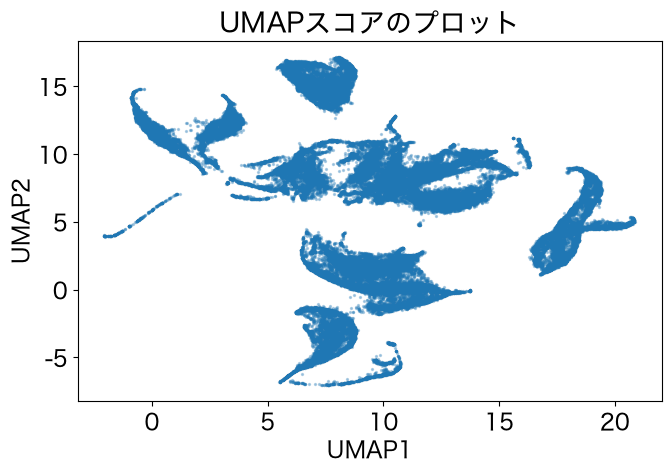

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import umap

# 前のPCAセルで作った autoscaled_dataset を使って、UMAPで2次元に圧縮します
# UMAPは近くにあるサンプル同士の関係を保ちながら、2次元の散布図にしやすい手法です
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=0,
)
umap_scores = umap_model.fit_transform(autoscaled_dataset)

umap_score = pd.DataFrame(
    umap_scores,
    index=dataset.index,
    columns=['UMAP1', 'UMAP2'],
)
umap_score.to_csv(output_dir / 'umap_score.csv')

plt.rcParams['font.size'] = 16
plt.figure(figsize=(7, 5))
plt.scatter(umap_score['UMAP1'], umap_score['UMAP2'], s=2, alpha=0.3)
plt.title('UMAPスコアのプロット')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()


# 階層的クラスタリング

階層的クラスタリングは、データ同士を少しずつまとめていき、どの順番でクラスターができたかを木構造で表す方法です。結果はデンドログラムとして表示できます。

**クラスタリング**とは、似ているデータ同士をグループに分けることです。このグループを**クラスター**と呼びます。正解ラベルを使わずに、データの特徴だけからグループを作るため、教師なし学習の一種です。**教師なし学習**とは、正解を教えずにデータの構造を見つける方法です。

**この手法で見たいこと**

階層的クラスタリングでは、どのサンプル同士が近いか、どのクラスター同士が後から結合されるかを見ます。単にクラスター番号を付けるだけでなく、似ているものが段階的にまとまる様子を確認できるのが特徴です。

**今回の構成**

今回の修正では、データをPCAで圧縮するのはデンドログラム作成のためだけにします。PCAやUMAPの図にクラスタリング結果を重ねるときは、前半ですでに作った元のPCA散布図 `score` と元のUMAP散布図 `umap_score` を使い、そこにクラスター番号で色を付けます。

**処理の流れ**

1. デンドログラムだけ、計算と表示を軽くするためにPCAで15次元へ圧縮します。
2. `dendrogram_sample_size` で指定した数だけサンプルを取り出します。
3. 取り出したサンプル同士の距離を計算します。
4. Ward法で、近いクラスター同士を順番に結合します。
5. 指定したクラスター数、ここでは9クラスターになるように木を切り、サンプルにクラスター番号を付けます。
6. そのクラスター番号を、元のPCA散布図と元のUMAP散布図に色として重ねます。

**距離とは何か**

距離は、2つのサンプルがどれくらい違うかを表す値です。今回使うユークリッド距離は、普通の直線距離です。2次元なら三平方の定理で計算する距離で、高次元でも同じ考え方を使います。

サンプル $x_i$ と $x_j$ のユークリッド距離は、次のように書けます。

$$
d(x_i, x_j) = \sqrt{(x_{i1}-x_{j1})^2 + (x_{i2}-x_{j2})^2 + \cdots + (x_{ip}-x_{jp})^2}
$$

ここで $p$ は変数の数です。デンドログラムでは、PCAで圧縮した15個の主成分を変数として使います。

**Ward法の考え方**

Ward法は、クラスターを結合したときに、クラスター内のばらつきができるだけ増えない組み合わせを選ぶ方法です。**重心**とは、クラスター内のサンプルの平均位置です。クラスター $A$ と $B$ を結合したときのばらつきの増加量は、直感的には次の式で表せます。

$$
\Delta(A,B) = \frac{|A||B|}{|A|+|B|}\|\bar{x}_A - \bar{x}_B\|^2
$$

$|A|$ はクラスター $A$ に入っているサンプル数、$\bar{x}_A$ はクラスター $A$ の重心です。$\|\bar{x}_A - \bar{x}_B\|$ は2つの重心の距離です。この値が小さいクラスター同士から結合します。

**図の読み方**

PCA表示やUMAP表示では、点の位置は前半で作った元の散布図と同じです。変わるのは点の色だけです。同じ色の点が近くに集まっていれば、階層的クラスタリングで似ていると判断されたサンプルが、PCAやUMAPの見え方でもまとまっていると考えられます。色が混ざっている場合は、クラスターの境界がはっきりしていない可能性があります。

**メリット**

- デンドログラムにより、サンプルがどの順番でまとまるかを確認できます。
- クラスター数を後から決めやすいです。木をどの高さで切るかを変えると、クラスター数を変えられます。
- PCAやUMAPの元の散布図に色を重ねることで、元の可視化結果を保ったままクラスタリング結果を確認できます。

**デメリット**

- サンプル数が多いと計算量とメモリ使用量が大きくなります。このデータは60,000サンプルあるため、デンドログラムは一部サンプルで描きます。
- 一度結合したクラスターは後から分割されません。途中で間違った結合が起きても戻れません。
- 距離の定義や結合法によって結果が変わります。今回はデンドログラム用にPCA 15次元、ユークリッド距離、Ward法という条件で見ています。


#### PCA

このコードでは、階層的クラスタリングの結果を、前半で作った元のPCA散布図に色として重ねます。点の位置は `score['PC1']` と `score['PC2']` を使うため、PCA散布図そのものは前半と同じです。

ここで変わるのは色だけです。色はデンドログラム用に選んだサンプルへ付けた階層的クラスタリングのクラスター番号を表します。つまり、「元のPCA図で見たときに、階層的クラスタリングのグループがどのように配置されるか」を確認する図です。


デンドログラム用PCAスコア: 60000 サンプル x 15 主成分
累積寄与率（15主成分）: 0.334


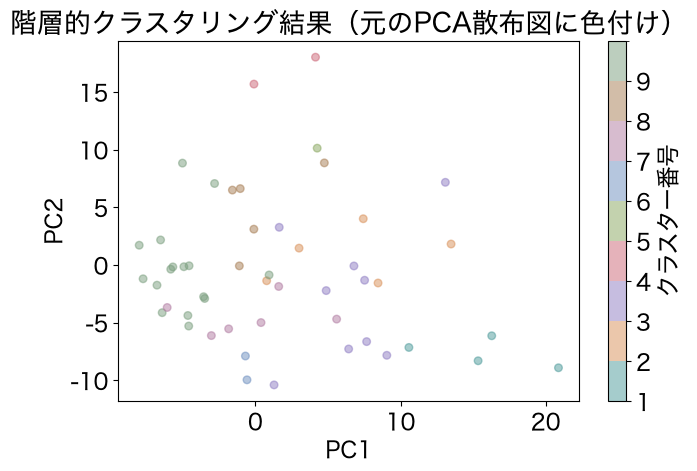

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.decomposition import PCA

set_japanese_font()

# 階層的クラスタリングで分けたいクラスター数です。k-meansと比べやすいように9にしています
number_of_hierarchical_clusters = 9
hierarchical_cluster_cmap, hierarchical_cluster_norm = make_cluster_colormap(number_of_hierarchical_clusters)

# デンドログラムに使うサンプル数です。大きくすると情報は増えますが、計算と表示が重くなります
# 例: 30, 50, 100 などに変更して試せます
dendrogram_sample_size = 50

# デンドログラムだけ、スライドの指示に合わせてPCAで10〜20次元へ圧縮します
dendrogram_pca_n_components = 15
hierarchical_random_state = 0

# 前のPCAセルで作った autoscaled_dataset を、デンドログラム用にだけPCA圧縮します
# PCA/UMAPの散布図に色を付けるときは、前半で作った score と umap_score を使います
dendrogram_pca = PCA(n_components=dendrogram_pca_n_components, random_state=0)
dendrogram_pca_array = dendrogram_pca.fit_transform(autoscaled_dataset)
dendrogram_pca_columns = [f'Dendrogram_PC{i}' for i in range(1, dendrogram_pca_n_components + 1)]
dendrogram_pca_scores = pd.DataFrame(
    dendrogram_pca_array,
    index=dataset.index,
    columns=dendrogram_pca_columns,
)

print(f'デンドログラム用PCAスコア: {dendrogram_pca_scores.shape[0]} サンプル x {dendrogram_pca_scores.shape[1]} 主成分')
print(f'累積寄与率（{dendrogram_pca_n_components}主成分）: {dendrogram_pca.explained_variance_ratio_.sum():.3f}')

# 階層的クラスタリングは全サンプルで行うと非常に重いため、指定した数だけサンプルを選びます
actual_dendrogram_sample_size = min(dendrogram_sample_size, len(dendrogram_pca_scores))
hierarchical_sample = dendrogram_pca_scores.sample(
    n=actual_dendrogram_sample_size,
    random_state=hierarchical_random_state,
)
hierarchical_sample.to_csv(output_dir / 'dendrogram_pca_scores_sample.csv')

# Ward法で階層的クラスタリングを実行します
# metric='euclidean' はユークリッド距離、method='ward' はクラスター内のばらつきが増えにくい結合法です
hierarchical_linkage = linkage(hierarchical_sample, metric='euclidean', method='ward')

# デンドログラムを指定したクラスター数で切り、各サンプルにクラスター番号を付けます
hierarchical_cluster_labels = fcluster(
    hierarchical_linkage,
    number_of_hierarchical_clusters,
    criterion='maxclust',
)
hierarchical_cluster_numbers = pd.DataFrame(
    hierarchical_cluster_labels,
    index=hierarchical_sample.index,
    columns=['hierarchical_cluster'],
)
hierarchical_cluster_numbers.to_csv(output_dir / 'hierarchical_cluster_numbers_sample.csv')

# 階層的クラスタリングの結果を、前半で作った元のPCA散布図に色として重ねます
hierarchical_pca_plot_data = score.loc[
    hierarchical_cluster_numbers.index,
    ['PC1', 'PC2'],
].join(hierarchical_cluster_numbers)

plt.rcParams['font.size'] = 16
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    hierarchical_pca_plot_data['PC1'],
    hierarchical_pca_plot_data['PC2'],
    c=hierarchical_pca_plot_data['hierarchical_cluster'],
    cmap=hierarchical_cluster_cmap,
    norm=hierarchical_cluster_norm,
    s=30,
    alpha=0.5,
)
plt.title('階層的クラスタリング結果（元のPCA散布図に色付け）')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='クラスター番号', ticks=range(1, number_of_hierarchical_clusters + 1))
plt.tight_layout()
plt.show()


#### UMAP

このコードでは、階層的クラスタリングの結果を、前半で作った元のUMAP散布図に色として重ねます。点の位置は `umap_score['UMAP1']` と `umap_score['UMAP2']` を使うため、UMAP散布図そのものは前半と同じです。

PCA表示とUMAP表示を比べると、同じクラスタリング結果でも見え方が変わることがあります。UMAPで同じ色がまとまって見える場合、近傍関係を保った2次元表示でもそのクラスターがまとまりやすいと考えられます。ただし、UMAPは図の形を厳密な距離として解釈しすぎないようにします。


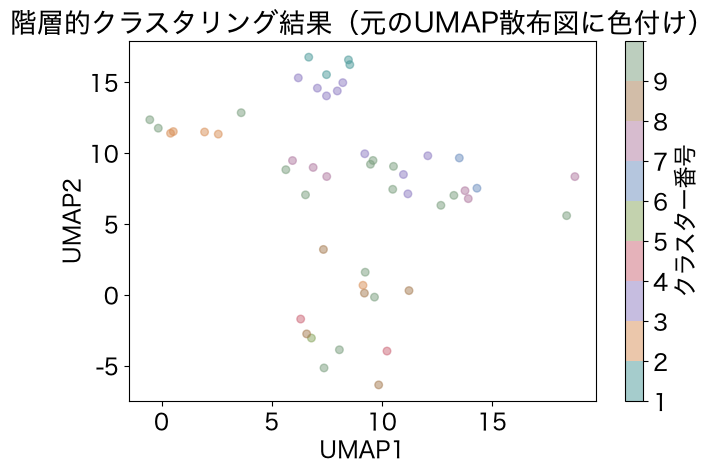

In [58]:
import matplotlib.pyplot as plt

set_japanese_font()

# 先ほどの階層的クラスタリング結果を、前半で作った元のUMAP散布図に色として重ねます
hierarchical_umap_plot_data = umap_score.loc[
    hierarchical_cluster_numbers.index,
    ['UMAP1', 'UMAP2'],
].join(hierarchical_cluster_numbers)

plt.rcParams['font.size'] = 16
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    hierarchical_umap_plot_data['UMAP1'],
    hierarchical_umap_plot_data['UMAP2'],
    c=hierarchical_umap_plot_data['hierarchical_cluster'],
    cmap=hierarchical_cluster_cmap,
    norm=hierarchical_cluster_norm,
    s=30,
    alpha=0.5,
)
plt.title('階層的クラスタリング結果（元のUMAP散布図に色付け）')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.colorbar(scatter, label='クラスター番号', ticks=range(1, number_of_hierarchical_clusters + 1))
plt.tight_layout()
plt.show()


#### デンドログラム

デンドログラムは、階層的クラスタリングの結合過程を木の形で表した図です。木の枝がどこでつながるかを見ることで、どのサンプル同士が近いか、どのグループ同士が遠いかを確認できます。

**この図で見たいこと**

デンドログラムでは、サンプルがどの順番で結合されるかを見ます。低い距離で結合されるサンプル同士は似ていると考えます。高い距離でようやく結合されるグループ同士は、比較的違いが大きいと考えます。

**軸の意味**

このノートブックでは横向きのデンドログラムを描きます。横軸の「距離」は、クラスター同士が結合されるときの遠さを表します。縦軸にはサンプル番号が表示されます。枝が右のほうで結合されるほど、遠いクラスター同士が結合されたという意味です。

**サンプル数を指定する理由**

この課題データは60,000サンプルあります。全サンプルをデンドログラムにすると、計算が重くなり、図にも60,000個のラベルが出て読めなくなります。そのため、`dendrogram_sample_size` で表示するサンプル数を指定します。最初は50程度にして、全体の雰囲気を見るのが扱いやすいです。

**注意点**

デンドログラムは、指定したサンプルだけで作った図です。そのため、この図だけで全60,000サンプルの構造を完全に説明することはできません。全体のクラスタリング結果はk-meansやPCA/UMAPの散布図と合わせて確認します。


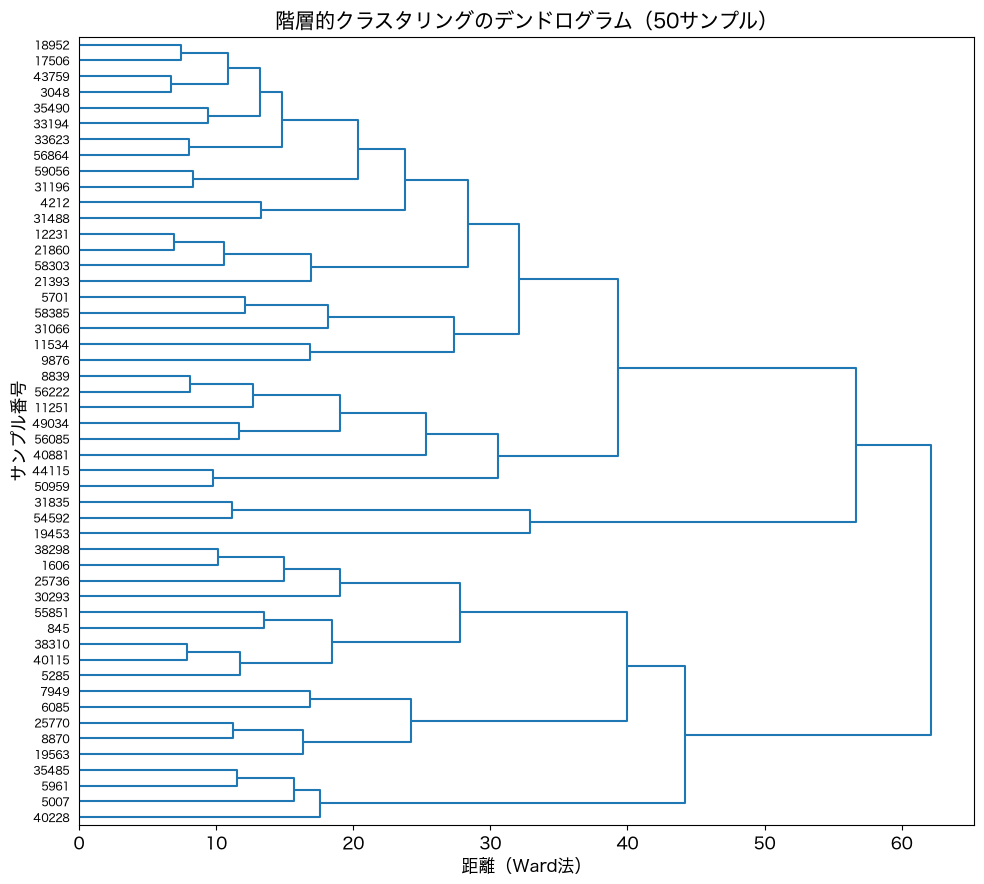

In [59]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

set_japanese_font()

# cell 10で作った hierarchical_linkage を使って、デンドログラムを描きます
# labels にはサンプル番号を入れるので、どのサンプル同士が近いかを確認できます
plt.rcParams['font.size'] = 12
plt.figure(figsize=(10, max(6, actual_dendrogram_sample_size * 0.18)))
dendrogram(
    hierarchical_linkage,
    labels=[str(sample_id) for sample_id in hierarchical_sample.index],
    orientation='right',
    color_threshold=0,
)
plt.title(f'階層的クラスタリングのデンドログラム（{actual_dendrogram_sample_size}サンプル）')
plt.xlabel('距離（Ward法）')
plt.ylabel('サンプル番号')
plt.tight_layout()
plt.show()


# 非階層的クラスタリング(k-means)

k-meansは、あらかじめクラスター数 $K$ を決めて、データを $K$ 個のグループに分ける非階層的クラスタリングです。階層的クラスタリングのような木構造は作らず、各点をどれか1つのクラスターに割り当てます。

**非階層的クラスタリングとは**

非階層的クラスタリングは、階層構造を作らずに、最終的なグループ分けを直接求める方法です。k-meansでは、最初に「5個に分ける」のようにクラスター数を決め、その数に合うように点を割り当てます。

**この手法で見たいこと**

k-meansでは、全60,000サンプルを大まかなグループに分け、前半で作った元のPCA図や元のUMAP図に色として重ねます。色ごとにまとまりが見えれば、データの中に似た画像のグループがある可能性があります。

**今回の構成**

k-meansでは、PCAで圧縮したデータではなく、標準化済みの元データ `autoscaled_dataset` を使ってクラスタリングします。PCAやUMAPは、クラスタリングの入力ではなく、結果を見やすく表示するための散布図として使います。

**処理の流れ**

1. PCAセルで作った標準化済みデータ `autoscaled_dataset` を使います。
2. クラスター数 $K$ を決めます。このノートブックでは `number_of_kmeans_clusters = 9` としています。
3. k-meansがクラスターの中心を仮に置きます。
4. 各サンプルを、一番近い中心のクラスターに割り当てます。
5. 各クラスターの中心を、所属するサンプルの平均位置に更新します。
6. 割り当てと中心の更新をくり返し、変化が小さくなったところで終了します。
7. 得られたクラスター番号を、元のPCA散布図と元のUMAP散布図に色として重ねます。

**数式の考え方**

k-meansでは、各クラスターの中心を $\mu_k$、サンプル $x_i$ が所属するクラスターを $c_i$ とします。$\mu_k$ はクラスター $k$ の中心で、所属している点の平均位置です。$c_i$ はサンプル $i$ がどのクラスターに入っているかを表します。

k-meansは、次の値をできるだけ小さくします。

$$
\sum_{i=1}^{n}\|x_i - \mu_{c_i}\|^2
$$

これは「各点と、その点が所属するクラスター中心との距離の二乗和」です。距離の二乗和が小さいほど、各点が自分のクラスター中心の近くに集まっていると考えます。

**図の読み方**

PCA表示とUMAP表示では、点の位置は前半で作った元の散布図と同じです。色だけがk-meansのクラスター番号になります。同じ色の点が近くにまとまっていれば、k-meansが似たサンプルを同じグループに分けられていると考えられます。色が混ざっているところは、クラスターの境界があいまいな領域です。

**メリット**

- サンプル数が多くても比較的速く計算できます。今回のような60,000サンプルでも扱いやすいです。
- 全サンプルにクラスター番号を付けられるため、後でCSVとして保存して確認できます。
- 元のPCAやUMAPの散布図に色として重ねると、可視化結果を保ったままデータのまとまりを確認できます。

**デメリット**

- クラスター数 $K$ を先に決める必要があります。適切な $K$ が分からない場合は、複数の値で試す必要があります。
- 初期値の置き方によって結果が変わることがあります。このノートブックでは `random_state=0` を指定して再現性を高めています。
- 丸い形に近いクラスターは得意ですが、曲がった形や複雑な形のクラスターは苦手です。


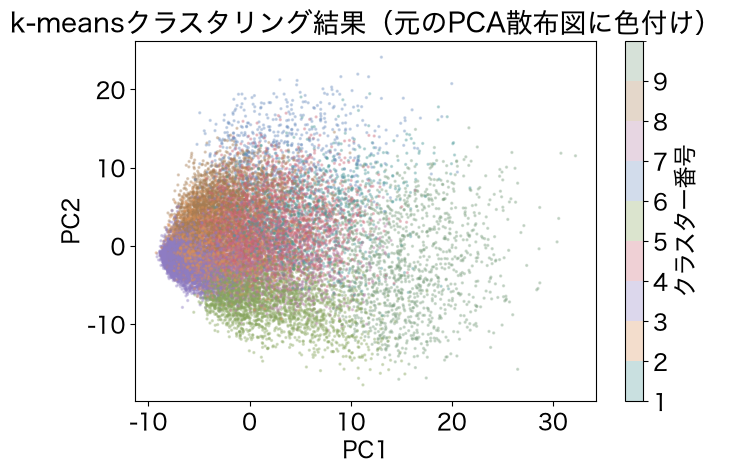

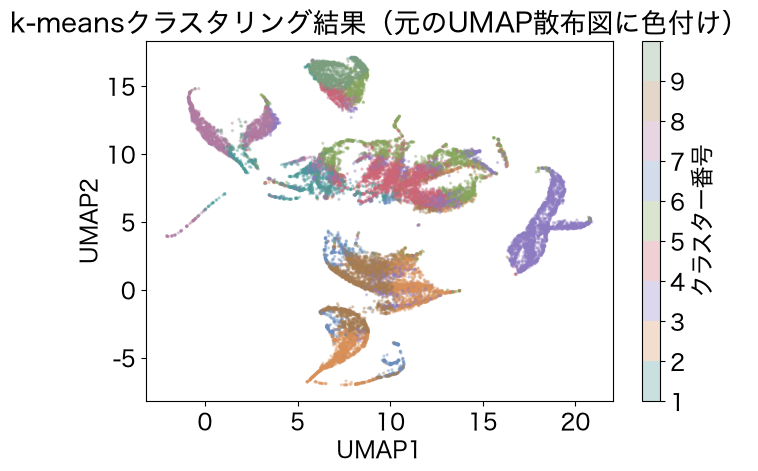

k-meansの各クラスターのサンプル数
kmeans_cluster
1     3675
2     7385
3    11811
4     8702
5     8198
6     1930
7     5658
8     8866
9     3775
Name: count, dtype: int64


In [60]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

set_japanese_font()

# k-meansで分けたいクラスター数です。階層的クラスタリングと比べやすいように9にしています
number_of_kmeans_clusters = 9


# PCAセル冒頭の cluster_colors を使って、k-meansの色を固定します
cluster_cmap, cluster_norm = make_cluster_colormap(number_of_kmeans_clusters)

# k-meansは全60,000サンプルに対して実行します
# 入力には、PCAで圧縮したデータではなく、標準化済みの元データ autoscaled_dataset を使います
kmeans = KMeans(n_clusters=number_of_kmeans_clusters, random_state=0, n_init='auto')
kmeans_cluster_labels = kmeans.fit_predict(autoscaled_dataset) + 1

kmeans_cluster_numbers = pd.DataFrame(
    kmeans_cluster_labels,
    index=dataset.index,
    columns=['kmeans_cluster'],
)
kmeans_cluster_numbers.to_csv(output_dir / 'kmeans_cluster_numbers.csv')

# 全サンプルのクラスター番号は保存し、図は見やすさのため最大20,000点を表示します
plot_sample_size = min(20000, len(kmeans_cluster_numbers))
kmeans_plot_index = kmeans_cluster_numbers.sample(n=plot_sample_size, random_state=0).index

# k-meansの結果を、前半で作った元のPCA散布図に色として重ねます
kmeans_pca_plot_data = score.loc[
    kmeans_plot_index,
    ['PC1', 'PC2'],
].join(kmeans_cluster_numbers)

plt.rcParams['font.size'] = 16
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    kmeans_pca_plot_data['PC1'],
    kmeans_pca_plot_data['PC2'],
    c=kmeans_pca_plot_data['kmeans_cluster'],
    cmap=cluster_cmap,
    norm=cluster_norm,
    s=2,
    alpha=0.3,
)
plt.title('k-meansクラスタリング結果（元のPCA散布図に色付け）')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='クラスター番号', ticks=range(1, number_of_kmeans_clusters + 1))
plt.tight_layout()
plt.show()

# k-meansの結果を、前半で作った元のUMAP散布図にも色として重ねます
kmeans_umap_plot_data = umap_score.loc[
    kmeans_plot_index,
    ['UMAP1', 'UMAP2'],
].join(kmeans_cluster_numbers)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    kmeans_umap_plot_data['UMAP1'],
    kmeans_umap_plot_data['UMAP2'],
    c=kmeans_umap_plot_data['kmeans_cluster'],
    cmap=cluster_cmap,
    norm=cluster_norm,
    s=2,
    alpha=0.3,
)
plt.title('k-meansクラスタリング結果（元のUMAP散布図に色付け）')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.colorbar(scatter, label='クラスター番号', ticks=range(1, number_of_kmeans_clusters + 1))
plt.tight_layout()
plt.show()

print('k-meansの各クラスターのサンプル数')
print(kmeans_cluster_numbers['kmeans_cluster'].value_counts().sort_index())


## k-meansクラスターごとの代表画像とシルエット係数

k-meansのクラスター番号だけでは、各クラスターがどのような画像を集めているか分かりにくいです。そこで、各クラスター中心に最も近い画像を代表画像として表示します。あわせて、クラスタリングのまとまり具合をシルエット係数で確認します。


In [ ]:
from IPython.display import display
from sklearn.metrics import silhouette_score

set_japanese_font()

# 各サンプルと各k-means中心との距離を計算し、クラスター中心に最も近い画像を代表画像にします
kmeans_distances = kmeans.transform(autoscaled_dataset)
representative_indices = []

for cluster_id in range(1, number_of_kmeans_clusters + 1):
    cluster_member_index = kmeans_cluster_numbers.index[
        kmeans_cluster_numbers['kmeans_cluster'] == cluster_id
    ]
    cluster_distances = kmeans_distances[
        dataset.index.get_indexer(cluster_member_index),
        cluster_id - 1,
    ]
    representative_sample_id = cluster_member_index[np.argmin(cluster_distances)]
    representative_indices.append(representative_sample_id)

representative_table = pd.DataFrame({
    'kmeans_cluster': range(1, number_of_kmeans_clusters + 1),
    'representative_sample_id': representative_indices,
})
representative_table.to_csv(output_dir / 'kmeans_representative_samples.csv', index=False)
display(representative_table)

# 代表画像を表示します
n_cols = min(5, number_of_kmeans_clusters)
n_rows = int(np.ceil(number_of_kmeans_clusters / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 2.4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, cluster_id, sample_id in zip(axes, range(1, number_of_kmeans_clusters + 1), representative_indices):
    image = dataset.loc[sample_id].to_numpy().reshape(28, 28)
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'Cluster {cluster_id}\nID: {sample_id}', fontsize=10)
    ax.axis('off')

for ax in axes[number_of_kmeans_clusters:]:
    ax.axis('off')

plt.suptitle('k-meansクラスターごとの代表画像')
plt.tight_layout()
plt.show()

# シルエット係数は計算が重いため、最大3000点で計算します
silhouette_sample_size = min(3000, len(autoscaled_dataset))
silhouette_index = kmeans_cluster_numbers.sample(n=silhouette_sample_size, random_state=0).index
silhouette_value = silhouette_score(
    autoscaled_dataset.loc[silhouette_index],
    kmeans_cluster_numbers.loc[silhouette_index, 'kmeans_cluster'],
)
print(f'k-meansのシルエット係数: {silhouette_value:.4f}')


# 正解ラベルとの比較

正解ラベルとは、各サンプルが本来どの種類に属しているかを表す答えです。今回の `MNICT_train_label.csv` では、先頭列の `label` が正解ラベルです。画像データなので、ラベルは0から9までの数字を表しています。

ここでは、非階層的クラスタリングであるk-meansの結果と、正解ラベルを比較します。k-meansは正解ラベルを見ずに、データの形だけを使ってサンプルを9個のクラスターに分けています。そのため、k-meansのクラスター番号1〜9は、正解ラベル0〜9と同じ番号になるとは限りません。

**この比較で見たいこと**

- k-meansで同じクラスターになった点が、正解ラベルでも同じ数字になっているかを見ます。
- PCA散布図とUMAP散布図の両方で、k-meansの色分けと正解ラベルの色分けを見比べます。
- 数値指標として、ARIとNMIを計算します。

**ARIとは**

ARIはAdjusted Rand Indexの略です。2つのグループ分けがどれくらい似ているかを表す指標です。1に近いほどよく一致し、0に近いほどランダムな分け方に近いと考えます。クラスター番号そのものが違っていても、同じサンプル同士が同じグループに入っているかで評価できます。

**NMIとは**

NMIはNormalized Mutual Informationの略です。2つのラベル付けが共有している情報の量を0から1の範囲で表します。1に近いほど、k-meansのクラスターから正解ラベルをよく説明できると考えます。

**クロス集計表の読み方**

クロス集計表は、行をk-meansのクラスター番号、列を正解ラベルとして、各組み合わせに何サンプル入っているかを数えた表です。1つの行で特定の正解ラベルに数が集中していれば、そのクラスターはその数字をよく集めていると考えられます。反対に、1つの行にいろいろな正解ラベルが混ざっていれば、そのクラスターは複数の数字をまとめてしまっていると考えます。

**図の読み方**

PCA図とUMAP図では、点の位置は前半で作った元の散布図と同じです。左側にk-meansの結果、右側に正解ラベルを並べて表示します。左右で似た色のまとまり方になっていれば、k-meansの結果が正解ラベルに近いと考えられます。ただし、k-meansのクラスター番号と正解ラベル番号は別物なので、色番号が完全に一致する必要はありません。


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

set_japanese_font()

# 正解ラベルCSVを探します。ファイルがある場合だけ、k-meansと正解ラベルを比較します
label_candidate_paths = [
    Path('MNICT_train_label.csv'),
    Path('prac') / 'MNICT_train_label.csv',
    Path('/Users/t-shuichi/Developer/seminar6/prac/MNICT_train_label.csv'),
]
label_path = None
for label_candidate_path in label_candidate_paths:
    if label_candidate_path.exists():
        label_path = label_candidate_path
        break

if label_path is None:
    true_label_numbers = None
    comparison_table = None
    print('MNICT_train_label.csv が見つからないため、正解ラベルとの比較はスキップします。')
else:
    # MNICT_train_label.csv は、先頭列 label が正解ラベルで、残りの列がピクセル値です
    label_dataset = pd.read_csv(label_path)
    true_labels = label_dataset['label'].astype(int)

    # 元データ dataset と同じ行番号で比較できるように、index をそろえます
    if len(true_labels) != len(dataset):
        raise ValueError('正解ラベルの行数と MNICT_train.csv のサンプル数が一致しません。')
    true_labels.index = dataset.index
    true_label_numbers = pd.DataFrame({'true_label': true_labels}, index=dataset.index)
    true_label_numbers.to_csv(output_dir / 'true_label_numbers.csv')

    # k-meansのクラスター番号と正解ラベルを1つの表にまとめます
    comparison_table = kmeans_cluster_numbers.join(true_label_numbers)
    comparison_table.to_csv(output_dir / 'kmeans_vs_true_labels.csv')

    # クラスター番号そのものは一致しなくてもよいので、ARIとNMIでグループ分けの近さを評価します
    ari_score = adjusted_rand_score(comparison_table['true_label'], comparison_table['kmeans_cluster'])
    nmi_score = normalized_mutual_info_score(comparison_table['true_label'], comparison_table['kmeans_cluster'])
    print(f'ARI（k-means と正解ラベルの一致度）: {ari_score:.3f}')
    print(f'NMI（k-means と正解ラベルの情報の近さ）: {nmi_score:.3f}')

    # クロス集計表で、各k-meansクラスターにどの正解ラベルが多いかを確認します
    cross_table = pd.crosstab(
        comparison_table['kmeans_cluster'],
        comparison_table['true_label'],
        rownames=['k-means cluster'],
        colnames=['true label'],
    )
    cross_table.to_csv(output_dir / 'kmeans_true_label_crosstab.csv')
    display(cross_table)

    # 図は見やすさのため最大20,000点にします。比較しやすいようにk-meansと同じサンプルを使います
    comparison_plot_index = kmeans_plot_index
    comparison_pca_plot_data = score.loc[comparison_plot_index, ['PC1', 'PC2']].join(comparison_table)
    comparison_umap_plot_data = umap_score.loc[comparison_plot_index, ['UMAP1', 'UMAP2']].join(comparison_table)

    # 正解ラベルは0〜9なので、0から9に対応するカラーマップを作ります
    true_label_cmap = ListedColormap(cluster_colors[:10])
    true_label_norm = BoundaryNorm([i - 0.5 for i in range(11)], true_label_cmap.N)

    # PCA上で、k-means結果と正解ラベルを左右に並べて比較します
    plt.rcParams['font.size'] = 14
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

    scatter_kmeans = axes[0].scatter(
        comparison_pca_plot_data['PC1'],
        comparison_pca_plot_data['PC2'],
        c=comparison_pca_plot_data['kmeans_cluster'],
        cmap=cluster_cmap,
        norm=cluster_norm,
        s=2,
        alpha=0.3,
    )
    axes[0].set_title('PCA: k-meansクラスタ')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    fig.colorbar(scatter_kmeans, ax=axes[0], label='k-means cluster', ticks=range(1, number_of_kmeans_clusters + 1))

    scatter_true = axes[1].scatter(
        comparison_pca_plot_data['PC1'],
        comparison_pca_plot_data['PC2'],
        c=comparison_pca_plot_data['true_label'],
        cmap=true_label_cmap,
        norm=true_label_norm,
        s=2,
        alpha=0.3,
    )
    axes[1].set_title('PCA: 正解ラベル')
    axes[1].set_xlabel('PC1')
    fig.colorbar(scatter_true, ax=axes[1], label='true label', ticks=range(10))

    plt.tight_layout()
    plt.show()

    # UMAP上でも、k-means結果と正解ラベルを左右に並べて比較します
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

    scatter_kmeans = axes[0].scatter(
        comparison_umap_plot_data['UMAP1'],
        comparison_umap_plot_data['UMAP2'],
        c=comparison_umap_plot_data['kmeans_cluster'],
        cmap=cluster_cmap,
        norm=cluster_norm,
        s=2,
        alpha=0.3,
    )
    axes[0].set_title('UMAP: k-meansクラスタ')
    axes[0].set_xlabel('UMAP1')
    axes[0].set_ylabel('UMAP2')
    fig.colorbar(scatter_kmeans, ax=axes[0], label='k-means cluster', ticks=range(1, number_of_kmeans_clusters + 1))

    scatter_true = axes[1].scatter(
        comparison_umap_plot_data['UMAP1'],
        comparison_umap_plot_data['UMAP2'],
        c=comparison_umap_plot_data['true_label'],
        cmap=true_label_cmap,
        norm=true_label_norm,
        s=2,
        alpha=0.3,
    )
    axes[1].set_title('UMAP: 正解ラベル')
    axes[1].set_xlabel('UMAP1')
    fig.colorbar(scatter_true, ax=axes[1], label='true label', ticks=range(10))

    plt.tight_layout()
    plt.show()


# デンドログラムのラベル比較

デンドログラムでは、枝のまとまりを見ることで「どのサンプル同士が似ていると判断されたか」を確認できます。ただし、普通のデンドログラムではサンプル番号しか表示されないため、その枝にどの正解ラベルが多いのかが分かりにくいです。

ここでは、デンドログラムに使ったサンプルだけを取り出し、各サンプルに対応する正解ラベルを貼り付けます。さらに、デンドログラムの左側に「サンプル番号 | 正解ラベル | 階層クラスタ番号」を表示します。各サンプルの行には番号だけを並べ、正解ラベルと階層クラスタ番号そのものを色付き文字で表示します。右側には同じ色対応の色帯も並べるので、枝のまとまりとラベルの対応を視覚的に確認できます。

**この図で見たいこと**

- 同じ大きな枝に、同じ正解ラベルのサンプルが多く集まっているかを見ます。
- 階層クラスタ番号と正解ラベルが、どの程度似たまとまりを作っているかを見ます。
- たとえば、ある大きな枝に正解ラベル `0` が多ければ、その枝は数字0に近い特徴を持つサンプル群だと考えられます。
- 色付き文字の正解ラベルと階層クラスタ番号を見比べることで、同じ枝の中で番号の対応がそろっているか、混ざっているかを読み取ります。

**注意点**

デンドログラムは `dendrogram_sample_size` で指定した一部サンプルだけを使っています。そのため、ここで分かるのは「選ばれたサンプルの中での傾向」です。全60,000サンプル全体の傾向は、k-meansと正解ラベルのクロス集計表やPCA/UMAP比較図と合わせて確認します。



true label,0,1,2,3,4,5,6,7,8,9
hierarchical cluster,,,,,,,,,,
1,4,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,4,0,0,1
3,5,0,0,1,0,2,0,0,1,0
4,0,0,0,0,0,0,0,1,0,1
5,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,0,1,0,0,1,0
7,0,1,4,0,0,0,0,0,1,0
8,0,0,0,0,0,0,0,2,0,3
9,0,1,2,4,2,0,3,2,2,0


,majority_true_label,majority_count,cluster_size,majority_ratio
hierarchical cluster,,,,
1,0,4,4,1.000000
2,6,4,5,0.800000
3,0,5,9,0.555556
4,7,1,2,0.500000
5,7,1,1,1.000000
6,5,1,2,0.500000
7,2,4,6,0.666667
8,9,3,5,0.600000
9,3,4,16,0.250000


階層クラスタごとに多い正解ラベル
階層クラスタ 1: 正解ラベル 0 が最多 (4/4, 100.00%)
階層クラスタ 2: 正解ラベル 6 が最多 (4/5, 80.00%)
階層クラスタ 3: 正解ラベル 0 が最多 (5/9, 55.56%)
階層クラスタ 4: 正解ラベル 7 が最多 (1/2, 50.00%)
階層クラスタ 5: 正解ラベル 7 が最多 (1/1, 100.00%)
階層クラスタ 6: 正解ラベル 5 が最多 (1/2, 50.00%)
階層クラスタ 7: 正解ラベル 2 が最多 (4/6, 66.67%)
階層クラスタ 8: 正解ラベル 9 が最多 (3/5, 60.00%)
階層クラスタ 9: 正解ラベル 3 が最多 (4/16, 25.00%)


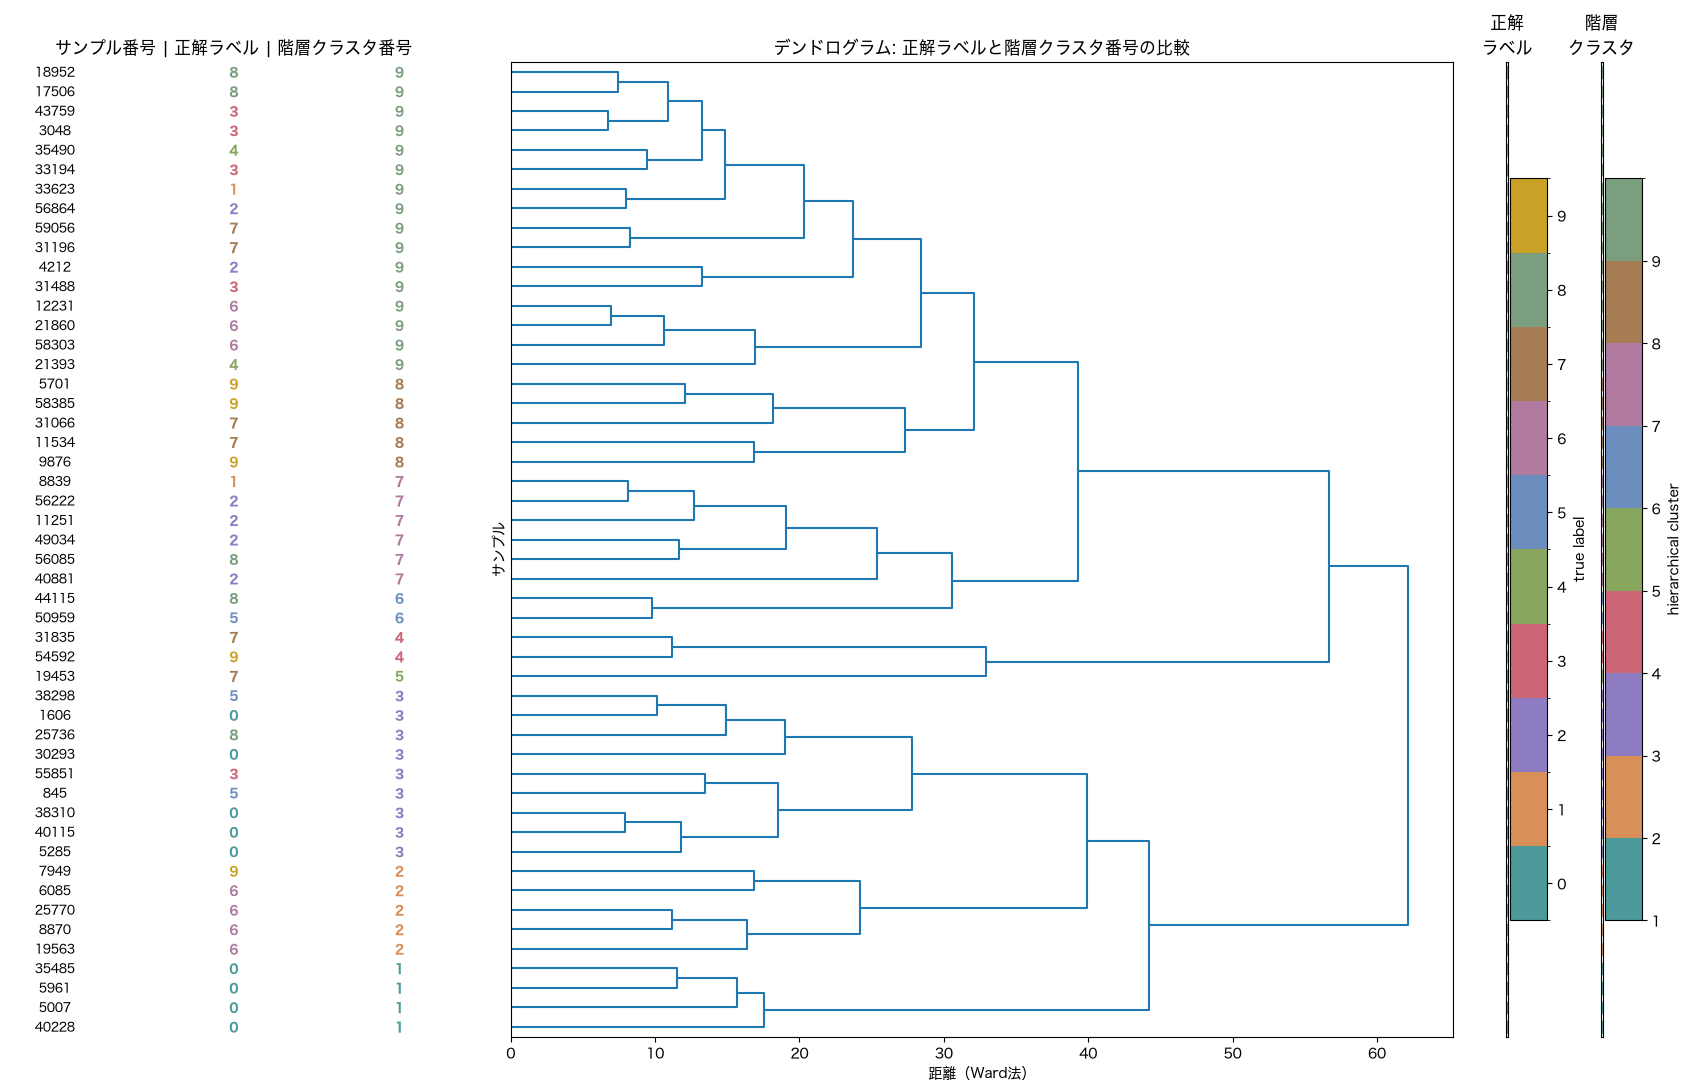

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.cluster.hierarchy import dendrogram

set_japanese_font()

# true_label_numbers がまだ作られていない場合でも、このセルだけで正解ラベルを読めるようにします
if 'true_label_numbers' not in globals():
    label_candidate_paths = [
        Path('MNICT_train_label.csv'),
        Path('prac') / 'MNICT_train_label.csv',
        Path('/Users/t-shuichi/Developer/seminar6/prac/MNICT_train_label.csv'),
    ]
    for label_candidate_path in label_candidate_paths:
        if label_candidate_path.exists():
            label_path = label_candidate_path
            break
    else:
        raise FileNotFoundError('MNICT_train_label.csv が見つかりません。CSVの場所を確認してください。')

    label_dataset = pd.read_csv(label_path)
    true_labels = label_dataset['label'].astype(int)
    if len(true_labels) != len(dataset):
        raise ValueError('正解ラベルの行数と MNICT_train.csv のサンプル数が一致しません。')
    true_labels.index = dataset.index
    true_label_numbers = pd.DataFrame({'true_label': true_labels}, index=dataset.index)

# デンドログラムに使ったサンプル番号、正解ラベル、階層クラスタ番号を1つの表にまとめます
# hierarchical_sample と hierarchical_cluster_numbers は、階層的クラスタリングのセルで作った変数です
dendrogram_label_table = hierarchical_cluster_numbers.join(true_label_numbers)
dendrogram_label_table = dendrogram_label_table.loc[hierarchical_sample.index]
dendrogram_label_table.to_csv(output_dir / 'dendrogram_sample_true_labels.csv')

# 階層クラスタごとに、どの正解ラベルが多いかを表で確認します
dendrogram_label_crosstab = pd.crosstab(
    dendrogram_label_table['hierarchical_cluster'],
    dendrogram_label_table['true_label'],
    rownames=['hierarchical cluster'],
    colnames=['true label'],
)
dendrogram_label_crosstab.to_csv(output_dir / 'dendrogram_cluster_true_label_crosstab.csv')
display(dendrogram_label_crosstab)

# 各階層クラスタで一番多い正解ラベルをまとめます。大きな枝がどの数字に対応しやすいかを見る手がかりです
majority_labels = dendrogram_label_crosstab.idxmax(axis=1).rename('majority_true_label')
majority_counts = dendrogram_label_crosstab.max(axis=1).rename('majority_count')
cluster_summary = pd.concat([majority_labels, majority_counts, dendrogram_label_crosstab.sum(axis=1).rename('cluster_size')], axis=1)
cluster_summary['majority_ratio'] = cluster_summary['majority_count'] / cluster_summary['cluster_size']
cluster_summary.to_csv(output_dir / 'dendrogram_cluster_majority_labels.csv')
display(cluster_summary)

print('階層クラスタごとに多い正解ラベル')
for cluster_id, row in cluster_summary.iterrows():
    print(
        f"階層クラスタ {cluster_id}: 正解ラベル {int(row['majority_true_label'])} が最多 "
        f"({int(row['majority_count'])}/{int(row['cluster_size'])}, {row['majority_ratio']:.2%})"
    )

# 色設定: 正解ラベル0〜9と階層クラスタ1〜9を、同じcluster_colorsで表示します
# 色は cluster_colors を編集するとまとめて変更できます
true_label_cmap = ListedColormap(cluster_colors[:10])
true_label_norm = BoundaryNorm([i - 0.5 for i in range(11)], true_label_cmap.N)

plt.rcParams['font.size'] = 10
fig, axes = plt.subplots(
    1,
    4,
    figsize=(17, max(7, actual_dendrogram_sample_size * 0.22)),
    gridspec_kw={'width_ratios': [3.8, 8, 0.35, 0.35]},
)

# no_labels=True にしてデンドログラム本体の葉ラベルは消します。
# 左側の列に、サンプル番号・正解ラベル・階層クラスタ番号を番号だけで描きます。
dendrogram_result = dendrogram(
    hierarchical_linkage,
    no_labels=True,
    orientation='right',
    color_threshold=0,
    ax=axes[1],
)
axes[1].set_title('デンドログラム: 正解ラベルと階層クラスタ番号の比較')
axes[1].set_xlabel('距離（Ward法）')
axes[1].set_ylabel('サンプル')

leaf_order = dendrogram_result['leaves']
ordered_sample_ids = hierarchical_sample.index[leaf_order]
ordered_true_labels = dendrogram_label_table.loc[ordered_sample_ids, 'true_label'].to_numpy()
ordered_hierarchical_clusters = dendrogram_label_table.loc[ordered_sample_ids, 'hierarchical_cluster'].to_numpy()

# dendrogramの葉は y=5, 15, 25, ... に配置されるため、その位置に文字と色帯を合わせます
leaf_y_positions = [5 + 10 * i for i in range(len(ordered_sample_ids))]
y_min = 0
y_max = 10 * len(ordered_sample_ids)

# ラベル用の列です。各サンプルの表示は番号だけにし、正解ラベルと階層クラスタ番号は対応する色で表示します。
label_axis = axes[0]
label_axis.set_xlim(0, 1)
label_axis.set_ylim(y_min, y_max)
label_axis.set_xticks([])
label_axis.set_yticks([])
label_axis.set_title('サンプル番号 | 正解ラベル | 階層クラスタ番号')
for spine in label_axis.spines.values():
    spine.set_visible(False)

for y_position, sample_id, true_label, hierarchical_cluster in zip(
    leaf_y_positions,
    ordered_sample_ids,
    ordered_true_labels,
    ordered_hierarchical_clusters,
):
    true_label_color = true_label_cmap(true_label_norm(int(true_label)))
    hierarchical_cluster_color = hierarchical_cluster_cmap(hierarchical_cluster_norm(int(hierarchical_cluster)))
    label_axis.text(
        0.10,
        y_position,
        f'{sample_id}',
        va='center',
        ha='center',
        color='black',
        fontsize=9,
    )
    label_axis.text(
        0.50,
        y_position,
        f'{int(true_label)}',
        va='center',
        ha='center',
        color=true_label_color,
        fontsize=9,
        fontweight='bold',
    )
    label_axis.text(
        0.87,
        y_position,
        f'{int(hierarchical_cluster)}',
        va='center',
        ha='center',
        color=hierarchical_cluster_color,
        fontsize=9,
        fontweight='bold',
    )

axes[2].scatter(
    [0] * len(ordered_true_labels),
    leaf_y_positions,
    c=ordered_true_labels,
    cmap=true_label_cmap,
    norm=true_label_norm,
    marker='s',
    s=70,
)
axes[2].set_title('正解\nラベル')
axes[2].set_ylim(y_min, y_max)
axes[2].set_xticks([])
axes[2].set_yticks([])

axes[3].scatter(
    [0] * len(ordered_hierarchical_clusters),
    leaf_y_positions,
    c=ordered_hierarchical_clusters,
    cmap=hierarchical_cluster_cmap,
    norm=hierarchical_cluster_norm,
    marker='s',
    s=70,
)
axes[3].set_title('階層\nクラスタ')
axes[3].set_ylim(y_min, y_max)
axes[3].set_xticks([])
axes[3].set_yticks([])

true_label_colorbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=true_label_cmap, norm=true_label_norm),
    ax=axes[2],
    ticks=range(10),
    fraction=0.9,
)
true_label_colorbar.set_label('true label')

hierarchical_colorbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=hierarchical_cluster_cmap, norm=hierarchical_cluster_norm),
    ax=axes[3],
    ticks=range(1, number_of_hierarchical_clusters + 1),
    fraction=0.9,
)
hierarchical_colorbar.set_label('hierarchical cluster')

plt.tight_layout()
plt.show()



# 用語まとめ

このノートブックで出てきた専門用語を、復習しやすいようにまとめます。

| 用語 | 意味 |
|---|---|
| サンプル | 解析対象の1つ1つのデータです。この課題では1枚の画像が1サンプルです。 |
| 変数 | サンプルを説明する列です。この課題では各ピクセル値が変数です。 |
| 次元 | 1つのサンプルを何個の数値で表すかという数です。784ピクセルなら784次元です。 |
| 標準化 | 平均を0、標準偏差を1にそろえる処理です。変数ごとのスケール差を小さくします。 |
| 分散 | 値が平均からどれくらいばらついているかを表す量です。 |
| 共分散 | 2つの変数が一緒に増減する傾向を表す量です。 |
| 主成分 | PCAで作られる新しい軸です。PC1、PC2のように呼びます。 |
| 固有値 | 主成分がどれくらい情報、つまりばらつきを持つかを表す値です。 |
| 固有ベクトル | 主成分の向きを表すベクトルです。元の変数をどう組み合わせるかを示します。 |
| スコア | 各サンプルが主成分軸上でどの位置にあるかを表す座標です。 |
| ローディング | 各変数が主成分にどれくらい関係しているかを表す値です。 |
| 寄与率 | ある主成分が全体の情報の何割を説明しているかを表します。 |
| 累積寄与率 | PC1から順に寄与率を足した値です。何個の主成分でどれくらい説明できるかを見る指標です。 |
| 近傍 | あるサンプルの近くにあるサンプルのことです。UMAPでは近傍関係を大切にします。 |
| 距離 | 2つのサンプルがどれくらい違うかを表す値です。小さいほど似ています。 |
| ユークリッド距離 | 普通の直線距離です。多次元でも同じ考え方で計算できます。 |
| クラスター | 似ているサンプルをまとめたグループです。 |
| クラスタリング | 正解ラベルを使わずに、似ているデータ同士をグループ分けする方法です。 |
| 階層的クラスタリング | データを少しずつ結合して、木構造としてグループを作る方法です。 |
| デンドログラム | 階層的クラスタリングの結合過程を表す木の図です。 |
| Ward法 | クラスター内のばらつきが増えにくい組み合わせから結合する方法です。 |
| 重心 | クラスター内のサンプルの平均位置です。クラスターの中心と考えられます。 |
| 非階層的クラスタリング | 木構造を作らず、最終的なグループ分けを直接求める方法です。 |
| k-means | クラスター中心と各点の距離が小さくなるように、データを $K$ 個に分ける方法です。 |
| random_state | 乱数を固定するための設定です。同じ結果を再現しやすくなります。 |
